# 房地产市场分析综合作业

请按照“一个小题 + 一个代码块”的格式完成作答。每个代码块只完成对应小题，便于后续检查和讲评。

覆盖知识点：`read_csv`、数据概览、缺失值处理、重复值处理、字符串字段清洗、类型转换、异常值处理、`str.split`、`str.extract`、`apply`、`lambda`、`pd.cut`、`groupby`、`agg`、相关性分析、`heatmap`、`histplot`、`boxplot`、`barplot`、`scatterplot`。

## 场景

公司房产业务产品部正在建设一套“二手房市场洞察报告”。这份报告将服务于运营、城市拓展、内容策略和管理层复盘，核心目标是把原始挂牌数据转化为可用于业务判断的结构化结论。

本次作业请你基于 `house_sales.csv` 完成一次完整的数据分析流程。输出结果应像一份产品部分析需求文档的落地版本：问题清楚、指标口径明确、图表有解释、结论能支持业务讨论。

## 数据说明

数据文件路径：`data/house_sales.csv`

字段口径如下：

- `city`：城市。
- `province`：省份。
- `address`：房源所在片区或地址信息。
- `name`：小区名称。
- `area`：建筑面积，原始值包含面积单位。
- `floor`：楼层描述。
- `rooms`：户型描述，例如几室几厅。
- `toward`：房屋朝向。
- `price`：房屋总价，原始值包含价格单位。
- `unit`：房屋单价，原始值包含单价单位。
- `year`：建造年份，原始值包含文字描述。
- `origin_url`：原始链接，本次分析不作为业务字段使用。

请注意：原始数据中存在缺失值、重复值、字符串单位和异常值。正式分析前必须完成清洗，否则后续统计结论可能失真。

## 第 1 题：数据读取与基础概览

业务要求：产品部需要先确认原始数据是否完整、字段是否符合预期，再决定后续分析口径。

1. 读取 `data/house_sales.csv`。
2. 输出总记录数和字段数量。
3. 查看前 5 行数据。
4. 查看字段类型和非空数量。
5. 简要说明哪些字段后续需要清洗或类型转换。

In [1]:
from pathlib import Path
import sys

from holoviews.plotting.bokeh.styles import font_size
from intake.source.cache import display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'data' / 'house_sales.csv').exists():
    NOTEBOOK_DIR = Path('07_房地产市场分析').resolve()

PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.constants import ZXS_LIST
# 设置中文字体和禁用Unicode减号
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者尝试其他中文字体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 Unicode 减号
# 读取csv文件
house_df = pd.read_csv(NOTEBOOK_DIR / 'data' / 'house_sales.csv')

In [2]:
# 输出总记录数和字段数量
print(house_df.shape[0])
print(house_df.columns)

106118
Index(['city', 'address', 'area', 'floor', 'name', 'price', 'province',
       'rooms', 'toward', 'unit', 'year', 'origin_url'],
      dtype='object')


In [3]:
# 查看前5行数据
house_df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


In [4]:
# 查看字段类型和非空数量
print(house_df.dtypes)
print(house_df.notna().sum())

city          object
address       object
area          object
floor         object
name          object
price         object
province      object
rooms         object
toward        object
unit          object
year          object
origin_url    object
dtype: object
city          106118
address       104452
area          105324
floor         104024
name          105564
price         105564
province      106118
rooms         104036
toward        105240
unit          105564
year           57736
origin_url    105564
dtype: int64


数据处理：需要删除不需要的列（origin_url），包含空值的行需要删除，检查是否有重复列并删除
地址需要分离出区域和具体的地址；area、price、rooms、unit、year需要提取出对应的数字；floor需要提取中floor_type(高、中、低层)；toward转成category类型


## 第 2 题：缺失值、无用字段与重复值处理

业务要求：正式统计前，需要移除不参与建模或分析的字段，并处理会影响统计口径的数据质量问题。

1. 删除 `origin_url` 字段。
2. 统计每个字段的缺失值数量。
3. 删除缺失记录，并说明删除前后的记录数变化。
4. 统计重复记录数量。
5. 删除重复记录，并说明去重后的样本量。

In [5]:
# 删除origin_url字段
house_df = house_df.drop(columns='origin_url')

In [6]:
# 统计每个字段缺失值数量
house_df.isna().sum()

city            0
address      1666
area          794
floor        2094
name          554
price         554
province        0
rooms        2082
toward        878
unit          554
year        48382
dtype: int64

In [7]:
# 删除缺失记录
before_del_na = house_df.shape[0]
house_df = house_df.dropna()
after_del_na = house_df.shape[0]
print(f"删除缺失记录前数量:{before_del_na}")
print(f"删除缺失记录后数量:{after_del_na}")

删除缺失记录前数量:106118
删除缺失记录后数量:57520


In [8]:
# 统计重复记录数量
house_df.duplicated().sum()

29416

In [9]:
# 删除重复记录，并说明去重后的样本量
before_drop_dup = house_df.shape[0]
house_df = house_df.drop_duplicates()
after_drop_dup = house_df.shape[0]
print(f"删除重复记录前数量:{before_drop_dup}")
print(f"删除重复记录后数量:{after_drop_dup}")

删除重复记录前数量:57520
删除重复记录后数量:28104


## 第 3 题：核心字段类型转换

业务要求：原始数据中的面积、总价、单价和建造年份包含中文单位，无法直接用于数值统计，需要统一转换为可计算字段。

1. 将 `area` 转换为数值型面积字段，单位保留为平方米。
2. 将 `price` 转换为数值型总价字段，单位保留为万元。
3. 将 `unit` 转换为数值型单价字段，单位保留为元/平方米。
4. 将 `year` 转换为整数年份。
5. 将 `toward` 转换为适合分类分析的类型。
6. 输出转换后的字段类型，确认转换结果。

In [10]:
# 数值类型转换
house_df['area'] = house_df['area'].str.replace('㎡','').astype(float)

In [11]:
house_df['price'] = house_df['price'].str.replace('万', '').astype(float)

In [12]:
house_df['unit'] = house_df['unit'].str.replace('元/㎡', '').astype(float)

In [13]:
house_df['year'] = house_df['year'].str.replace('年建', '').astype(int)

In [14]:
house_df['toward'] = house_df['toward'].astype('category')

In [15]:
house_df.dtypes

city          object
address       object
area         float64
floor         object
name          object
price        float64
province      object
rooms         object
toward      category
unit         float64
year           int32
dtype: object

## 第 4 题：异常值过滤

业务要求：极端面积和极端价格会影响市场整体判断，需要在保留常规住宅样本的前提下做基础异常值处理。

1. 保留 `area` 在 20 到 600 平方米之间的记录。
2. 使用 IQR 思路识别并过滤 `price` 的极端异常值。
3. 输出过滤前后的样本量。
4. 简要说明异常值处理会如何影响均价、分布图和城市对比。

In [16]:
# 保留area在20-600平方米之间的记录
house_df = house_df[(house_df['area'] >= 20) & (house_df['area'] <= 600)]

In [17]:
# 使用IQR（四分位距）识别并过滤price的异常值
q1 = house_df['price'].quantile(0.25)
q3 = house_df['price'].quantile(0.75)
iqr = q3 - q1
high_price = q3 + 1.5 * iqr
low_price = q3 - 1.5 * iqr
before_filter_price = house_df.shape[0]
house_df = house_df[(house_df['price'] >= low_price) & (house_df['price'] <= high_price)]
after_filter_price = house_df.shape[0]
print(f"过滤异常价格前数量:{before_filter_price}")
print(f"过滤异常价格后数量:{after_filter_price}")

过滤异常价格前数量:28082
过滤异常价格后数量:25852


异常值处理后会均价更加符合实际居民购房数据、分布图更集中、城市对比数据也更可信

## 第 5 题：区域、楼层、户型和楼龄特征构造

业务要求：原始字段无法直接支持运营分析，需要构造更接近业务语言的特征字段。

1. 从 `address` 中提取 `district`，表示区域或板块信息。
2. 从 `floor` 中提取 `floor_type`，表示楼层类型。
3. 构造 `zxs`，标记房源所在城市是否为北京、上海、天津、重庆。
4. 从 `rooms` 中提取 `bedrooms`，表示卧室数量。
5. 从 `rooms` 中提取 `livingrooms`，表示客厅数量。
6. 根据建造年份计算 `building_age`。
7. 查看新字段的前几行，确认字段构造结果。

In [18]:
house_df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


In [19]:
# 从 `address` 中提取 `district`，表示区域或板块信息
house_df.loc['district'] = house_df['address'].str.split('-').str[0]

In [20]:
# 从 `floor` 中提取 `floor_type`，表示楼层类型
house_df['floor_type'] = house_df['floor'].str.split('（').str[0].astype('category')

In [21]:
# 构造 `zxs`，标记房源所在城市是否为北京、上海、天津、重庆
house_df['zxs'] = house_df['province'].isin(ZXS_LIST).astype(int)

In [22]:
# 从room中提取bedrooms, livingrooms
house_df['bedrooms'] = house_df['rooms'].str.split('室').str[0].fillna(0).astype(int)
house_df['livingrooms'] = house_df['rooms'].str.extract(r'(\d+)厅').fillna(0).astype(int)

In [23]:
# 计算building_age
house_df['building_age'] = 2026 - house_df['year']

In [24]:
# 查看新字段的前几行
house_df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,floor_type,zxs,bedrooms,livingrooms,building_age
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,中层,0,3,2,13.0
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,中层,0,3,2,7.0
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,中层,0,2,1,9.0
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,高层,0,2,1,7.0
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,中层,0,4,2,14.0


## 第 6 题：价格分层字段构造

业务要求：产品部希望把房源总价划分为几个层级，方便后续对不同价格带房源进行对比。

1. 使用 `pd.cut` 将 `price` 划分为低价、中价、高价、豪华四个层级。
2. 新增字段 `price_labels` 保存分层结果。
3. 统计每个价格层级的房源数量。
4. 简要说明各层级样本是否均衡。

In [25]:
# 给房源分层
house_df['price_labels'] = pd.cut(house_df['price'], bins=4, labels=['低价', '中价', '高价', '豪华'])

In [26]:
# 统计每个价格层级的房源数量
house_df['price_labels'].value_counts()

低价    11776
中价     8986
高价     3538
豪华     1552
Name: price_labels, dtype: int64

低价和中价的房子样本多，高价和豪华的房子样本少，各层样本不均衡

## 第 7 题：房价整体分布分析

业务要求：管理层希望先了解当前样本中的二手房总价整体处于什么水平，以及主力价格区间在哪里。

1. 输出 `price` 的描述性统计结果。
2. 使用分布图展示全国样本总价分布，并叠加平滑趋势。
3. 判断总价分布是否集中、是否偏态。
4. 写出主力价格区间的大致判断。

In [27]:
# 输出price的描述性统计结果
house_df['price'].describe()

count    25852.000000
mean       118.245272
std         60.483783
min         27.500000
25%         72.600000
50%        105.000000
75%        150.000000
max        306.000000
Name: price, dtype: float64

<AxesSubplot:xlabel='price', ylabel='Count'>

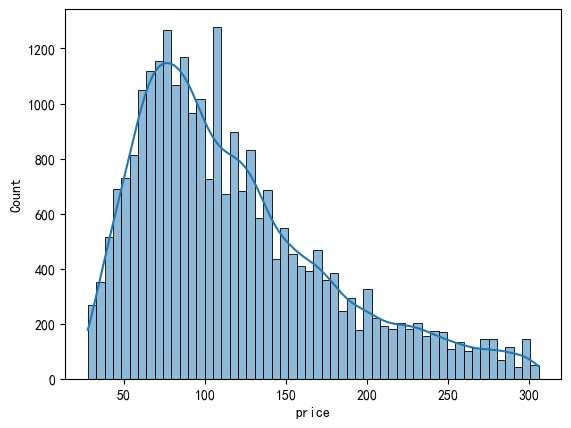

In [28]:
# 使用分布图展示全国样本总价分布，并叠加平滑趋势
sns.histplot(house_df, x='price', kde=True)

总价分布集中，左偏
主力价格在70-100万左右

## 第 8 题：影响房价的数值变量分析

业务要求：产品部需要识别哪些数值字段与总价关系更明显，为后续推荐排序和分析看板设计提供依据。

1. 选择总价、面积、单价、楼龄、卧室数、客厅数、是否直辖市等数值字段。
2. 计算这些字段之间的相关系数。
3. 按与 `price` 的相关性大小进行排序。
4. 绘制相关性热力图。
5. 说明哪些变量与总价关系更明显，并提醒相关性不等于因果关系。

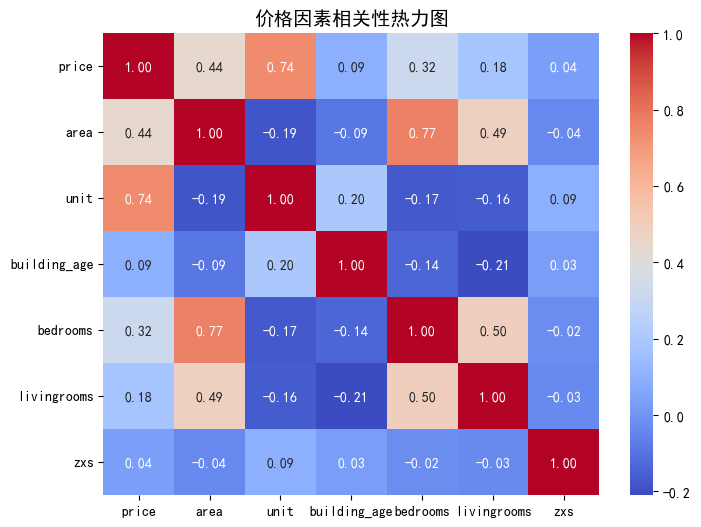

In [29]:
# 计算不同因素的相关系数
factor_corr = house_df[['price', 'area', 'unit', 'building_age', 'bedrooms', 'livingrooms', 'zxs']].corr()
# 按照与price的相关性进行排序
factor_corr['price'].sort_values(ascending=False)[1:]
# 绘制相关性热力图
plt.figure(figsize=(8, 6))
# annot 显示数据 fmt 格式(保留两位小数)
sns.heatmap(factor_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('价格因素相关性热力图',  fontsize=14, color='black')
plt.show()

单价、面积和卧室数量与总价关系更密切。

## 第 9 题：城市价格差异分析

业务要求：城市运营团队希望识别单价较高的城市，并比较这些城市的总价分布情况。

1. 按 `city` 分组，统计总价均值、总价中位数、房源数量、单价均值和单价中位数。
2. 按单价均值筛选排名前 10 的城市。
3. 使用箱线图比较这些城市的总价分布。
4. 说明城市排名是否可能受到样本量影响。

In [30]:
# 按city分组，统计总价均值、总价中位数、房源数量、单价均值和单价中位数
house_city_group = house_df.groupby('city').aggregate({
    'price':['mean','median'],
    'unit': ['mean', 'median']
}).join(house_df.groupby('city').size().rename('count'))

C:\Users\19808\AppData\Local\Temp\ipykernel_50428\3464952897.py:2: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  house_city_group = house_df.groupby('city').aggregate({


In [31]:
# 按单价均值筛选排名前10的城市
top10_city_index = house_city_group.sort_values(('price', 'mean'), ascending=False).head(10).index
top10_city_df = house_df[house_df['city'].isin(top10_city_index)]

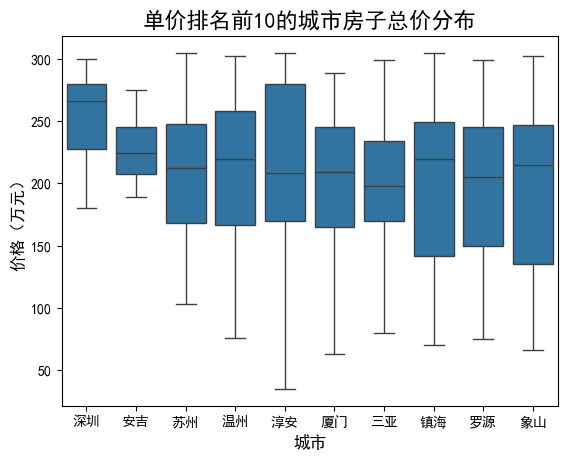

In [32]:
# 使用箱线图比较城市的总价分布
sns.boxplot(top10_city_df, x='city', y='price', order=top10_city_index)
plt.title('单价排名前10的城市房子总价分布', fontsize=16, color='black')
plt.xlabel('城市', fontsize=12)
plt.ylabel('价格（万元）', fontsize=12)
plt.show()

不同城市的样本量不同，可能受影响

## 第 10 题：价格分层特征差异分析

业务要求：产品部希望知道高价房源和低价房源在面积、楼龄、单价、直辖市占比等方面有什么差异。

1. 按 `price_labels` 分组，统计面积、楼龄、单价、直辖市占比。
2. 至少绘制两张图，对比不同价格层级的面积和楼龄差异。
3. 判断高价房源是否更大、是否更集中在核心城市、楼龄是否更低或更高。
4. 说明不同价格层级样本量差异是否会影响判断。

In [33]:
# 按价格分组，统计面积、楼龄、单价、直辖市占比
price_group = house_df.groupby('price_labels').agg({
    'building_age': 'mean',
    'area': ['mean', 'median'],
    'unit': 'mean',
    'zxs': 'mean'
}).join(house_df.groupby('price_labels').size().rename('count'))
price_group

C:\Users\19808\AppData\Local\Temp\ipykernel_50428\1298295301.py:2: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  price_group = house_df.groupby('price_labels').agg({


,"(building_age, mean)","(area, mean)","(area, median)","(unit, mean)","(zxs, mean)",count
price_labels,,,,,,
低价,12.478091,91.607968,91.0,8029.089079,0.003567,11776
中价,12.944914,108.457294,104.0,12477.941465,0.007790,8986
高价,13.887790,122.120164,120.0,17435.071227,0.007349,3538
豪华,14.215206,136.191669,134.0,21678.985180,0.016108,1552


<AxesSubplot:title={'center':'不同价格层次的楼龄差异'}, xlabel='price_labels', ylabel='楼龄（年）'>

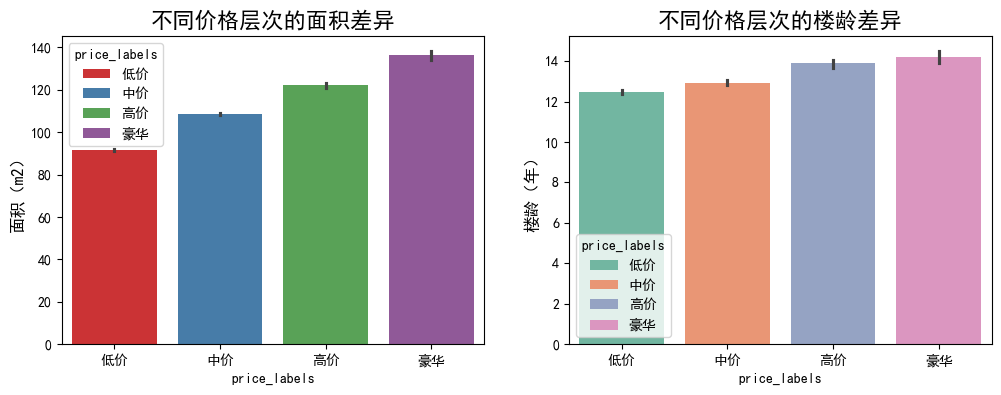

In [34]:
# 绘制两张图，对比不同价格层次的面积和楼龄差异
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title('不同价格层次的面积差异', fontsize=16, color='black')
plt.ylabel('面积（m2）',fontsize=12, color='black')
sns.barplot(data=house_df, x='price_labels', y='area', estimator='mean', palette='Set1', hue='price_labels')

plt.subplot(1, 2, 2)
plt.title('不同价格层次的楼龄差异', fontsize=16, color='black')
plt.ylabel('楼龄（年）',fontsize=12, color='black')
sns.barplot(data=house_df, x='price_labels', y='building_age', estimator='mean', palette='Set2', hue='price_labels')

#### 高价房源面积更大，更集中在核心城市（如直辖市），楼龄更高。
#### 由于低价和中价层次样本量相较于高价和豪华层次的较多，会影响判断

## 第 11 题：户型市场表现分析

业务要求：户型是用户筛选房源的重要条件，产品部需要了解不同卧室数量房源的价格、面积和供给情况。

1. 按 `bedrooms` 分组，统计总价均值、总价中位数、单价中位数、面积中位数和房源数量。
2. 使用合适图表展示面积、总价和户型之间的关系。
3. 判断主力户型和高总价户型是否一致。
4. 对样本量很少的户型，避免做过度解释。

In [35]:
bedroom_group = house_df.groupby('bedrooms').aggregate({
    'price':['mean', 'median'],
    'unit': 'median',
    'area': 'median'
}).join(house_df.groupby('bedrooms').size().rename('count'))
bedroom_group

C:\Users\19808\AppData\Local\Temp\ipykernel_50428\2044228505.py:1: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  bedroom_group = house_df.groupby('bedrooms').aggregate({


,"(price, mean)","(price, median)","(unit, median)","(area, median)",count
bedrooms,,,,,
0,69.384615,55.0,10000.0,79.000,14
1,65.967446,53.0,11427.0,47.000,1378
2,103.837077,95.0,11612.5,84.095,7686
3,123.625691,109.0,9840.5,110.105,13874
4,152.966429,139.9,9887.5,140.000,2498
5,167.835338,157.0,8696.0,187.390,311
6,195.852703,188.0,8504.5,221.000,74
7,163.500000,145.5,5580.0,273.000,8
8,160.000000,126.5,5043.0,281.500,6


Text(0, 0.5, '总价（万元）')

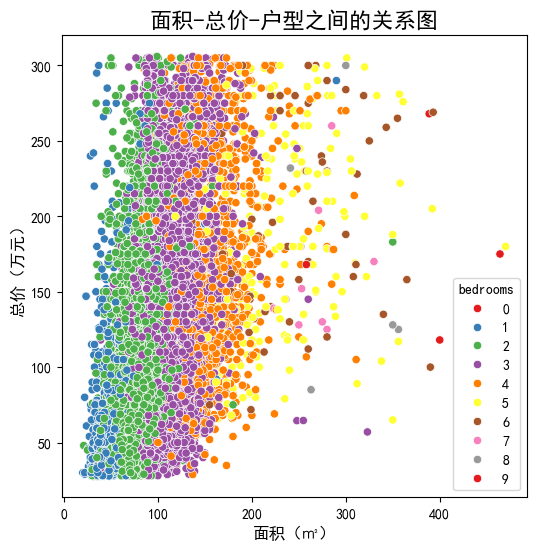

In [36]:
# 散点图适合展示面积、总价和户型之间的关系
plt.figure(figsize=(6,6))
sns.scatterplot(house_df, x='area', y='price', hue='bedrooms', palette='Set1')
plt.title('面积-总价-户型之间的关系图', fontsize=16)
plt.xlabel('面积（㎡）',fontsize=12)
plt.ylabel('总价（万元）',fontsize=12)

#### 主力户型与高总价户型不一致

## 第 12 题：朝向价格差异分析

业务要求：朝向是房源详情页的重要卖点，产品部希望判断主要朝向之间是否存在明显价格差异。

1. 按 `toward` 分组，统计总价均值、总价中位数、单价中位数、楼龄均值和房源数量。
2. 优先筛选样本量较大的主要朝向进行展示。
3. 使用箱线图展示主要朝向的总价分布。
4. 说明哪些朝向价格更高，并指出是否可能受到城市、面积、楼龄等因素影响。

In [37]:
house_df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,floor_type,zxs,bedrooms,livingrooms,building_age,price_labels
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,中层,0,3,2,13.0,中价
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,中层,0,3,2,7.0,中价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,中层,0,2,1,9.0,低价
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,高层,0,2,1,7.0,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,中层,0,4,2,14.0,中价


In [38]:
# 按朝向分组并统计总价、单价、面积、楼龄、房源数量
toward_group = house_df.groupby('toward').aggregate({
    'price':['mean', 'median'],
    'unit': 'median',
    'building_age': 'mean'
}).join(house_df.groupby('toward').size().rename('count'))
toward_group

C:\Users\19808\AppData\Local\Temp\ipykernel_50428\903003569.py:2: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  toward_group = house_df.groupby('toward').aggregate({


,"(price, mean)","(price, median)","(unit, median)","(building_age, mean)",count
toward,,,,,
东北向,115.464519,100.0,12198.0,13.625000,104
东南向,116.210703,105.0,10899.0,11.955533,967
东向,111.651553,95.5,11500.0,13.769417,412
东西向,100.081879,83.0,9048.0,16.442953,149
北向,94.449801,76.0,11780.0,14.147410,251
南北向,120.313937,105.0,10000.0,13.083695,14756
南向,115.861176,105.0,10833.0,12.559899,8673
西北向,120.529084,105.0,12290.0,14.557252,131
西南向,142.027309,140.0,13582.0,14.469880,249


D:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:2120: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  new_ix = Index(new_ix)
C:\Users\19808\AppData\Local\Temp\ipykernel_50428\3722768736.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_tow_data.loc[:, 'toward'] = filtered_tow_data['toward'].astype(str)


Text(0, 0.5, '总价（万元）')

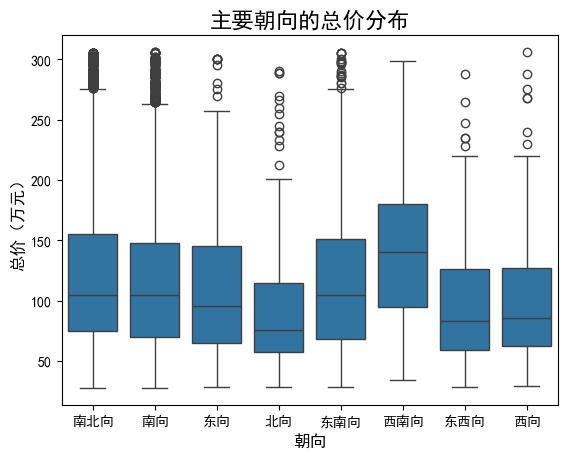

In [39]:
# 筛选样本量较大的主要朝向展示
top8_tow_ind = house_df['toward'].value_counts().head(8).index
# 过滤数据
filtered_tow_data = house_df[house_df['toward'].isin(top8_tow_ind)]
# 使用 .loc[] 来确保在原始 DataFrame 上进行修改
filtered_tow_data.loc[:, 'toward'] = filtered_tow_data['toward'].astype(str)
# 使用箱线图展示主要朝向总价分布
sns.boxplot(filtered_tow_data, x='toward', y='price')
plt.title('主要朝向的总价分布', fontsize=16)
plt.xlabel('朝向',fontsize=12)
plt.ylabel('总价（万元）',fontsize=12)

## 第 13 题：房地产市场综合分析小结

业务要求：请基于前面的处理结果，完成一段 5-8 句话的产品分析结论。

小结至少包含：

1. 市场整体价格分布特征。
2. 城市价格差异和可能原因。
3. 高价房源的主要特征。
4. 户型和朝向的分析发现。
5. 本次分析的限制，例如样本量、异常值过滤、字段缺失或城市结构差异。

本题写在 Markdown 中即可。

1.低价、中价房子占市场的大多数
2.不同城市的价格差异大，可能和当地经济情况、收入有关。
3.面积大，单价贵，直辖市比例高（地段好）
4.南北向和南向的房子数量多，且人们更愿意为南向和南北向的房子买单
5.样本量不均衡